[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gh-ip/TAE_project_1/blob/main/tae_cs1_gradient_descent_optimization.ipynb)

# Gradient Descent on a Quadratic Equation & Loss Function
This notebook implements basic gradient descent techniques on a quadratic function with a simple loss function using NumPy. It demonstrates the effect of different step sizes and includes deterministic plots.


In [102]:
### Setup & Imports
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")

# Ensure reproducibility
np.random.seed(42)

#save figures deterministically by setting them to True
save_figs=True  #Set to false to Not save


## Implementation of a standard Quadratic Function Optimization
(1) Python implementation of basic Quadrative Function of form  $f(x) = ax^2 + bx + c$
(2) The slope of the derivative of the function is $f'(x) = 2ax + b$

### Gradient Descent Approach to find the **minimum**
Gradient descent is an optimization algorithm that can help  optimize the loss function more efficiently than a "manual" approach.
By **minimizing the loss function** (also called "objective function" or "cost function"), one can find the value of $(x)$ that makes $f(x)$ as small as possible.<br>
The derivative of the function (2) gives the slope at any point.<br>

Gradient descent does this by repeatedly updating:<br>
$x_{\text{new}} = x_{\text{old}} - \alpha \cdot f'(x_{\text{old}})$

Where:
- $\alpha$ = learning rate (step size)
- $f'(x)$ = derivative (slope)


To find the minimum of a function, one keeps moving in the direction where the function decreases the fastest — the negative gradient<br>
The actual minimum of the Quadratic equation occurs at 
$(x) = -\frac{b}{2a}$

### Current Usecase
For the current case, the following quadratic equation use case is implemented for Gradient Function Optimization;

Quadratic Equation is $f(x) = 3x^2 + 2x + 1$,<br>
it's slope (or derivative) is  $f'(x) = 6x + 2$

And the minimum occurs at :
$x = -\frac{2}{2 \cdot 3} = -\frac{1}{3} \approx -0.333$


In [103]:
### Quadratic Function Optimization
# Define a simple quadratic function: f(x) = ax^2 + bx + c
def quadratic(x):
    return 3 * x**2 + 2 * x + 1

# Gradient: f'(x) = 6x + 2
def quadratic_grad(x):
    return 6 * x + 2

# Gradient descent implementation
def gradient_descent_quadratic(start_x, learning_rate, iterations):
    x = start_x
    history = [x]
    for _ in range(iterations):
        grad = quadratic_grad(x)
        x -= learning_rate * grad
        history.append(x)
    return history


### Visualization of Step Size Effects on Quadratic Function Optimization
* Plot below visualises the impact of stepsize, taking three different scaled step sizes of 0.01, 0.1 and 0.5.<br> 
* Smaller steps (learning rate) lead to slow convergence, while a large one risks overshooting the minimum as observed below. Very small steps may fail to reach the minimum as well exhausting the entire iteration range <br>
* Viually, Gradient Descent is aken to taking small steps downhill until the bottom is reached.     

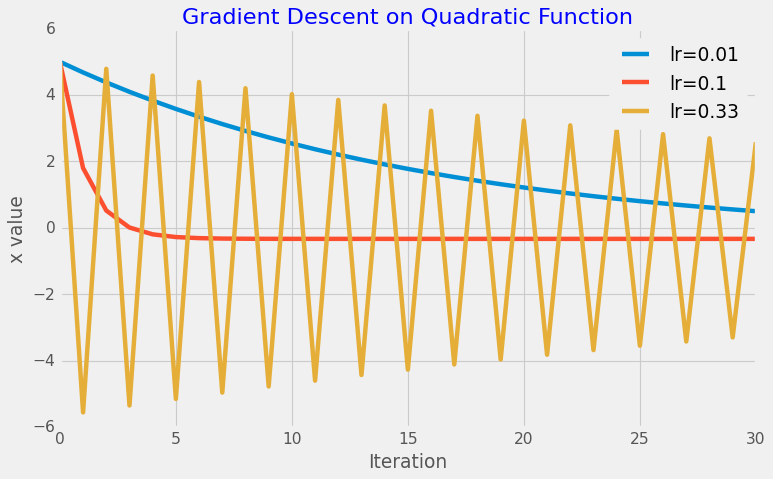

In [113]:
### Visualizing Step Size Effects
# Try different learning rates
learning_rates = [0.01, 0.1, 0.33]
start_x = 5
iterations = 30
path=[]

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    path = gradient_descent_quadratic(start_x, lr, iterations)
    plt.plot(path, label=f'lr={lr}')
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.title('Gradient Descent on Quadratic Function', color='b')
plt.legend()
plt.grid(True)
if save_figs==True:
    plt.savefig("step_size_effects.png")
plt.show()


### Numerical listing of learning rate impact from the visualisation 

In [112]:
path=[]
for lr in learning_rates:
    path = gradient_descent_quadratic(start_x, lr, iterations)
    print(f'learning_rate={lr:.2f}: {path}')


learning_rate=0.01: [5, 4.68, 4.3792, 4.096448, 3.83066112, 3.5808214528, 3.345972165632, 3.1252138356940797, 2.917701005552435, 2.722638945219289, 2.5392806085061315, 2.3669237719957636, 2.2049083456760177, 2.0526138449354567, 1.9094570142393292, 1.7748895933849695, 1.6483962177818714, 1.5294924447149592, 1.4177228980320615, 1.3126595241501378, 1.2138999527011296, 1.1210659555390619, 1.0338019982067181, 0.951773878314315, 0.8746674456154562, 0.8021873988785289, 0.7340561549458171, 0.6700127856490681, 0.609812018510124, 0.5532232973995166, 0.5000298995555456]
learning_rate=0.10: [5, 1.7999999999999998, 0.5199999999999998, 0.007999999999999896, -0.19680000000000003, -0.27872, -0.31148800000000004, -0.32459520000000003, -0.32983808000000003, -0.331935232, -0.3327740928, -0.33310963712, -0.333243854848, -0.3332975419392, -0.33331901677568, -0.333327606710272, -0.3333310426841088, -0.3333324170736435, -0.3333329668294574, -0.33333318673178297, -0.3333332746927132, -0.33333330987708526, -0.

## Implementation of a Gradient Discent on simple Linear Regression
Gradient Descent is used in training models like linear regression, where it minimizes Mean Squared Error (MSE) to find the best-fit line


In [85]:
### Simple Loss Function Example (Linear Regression)
# Generate synthetic data
X = np.linspace(0, 10, 100)
true_slope = 2.5
true_intercept = -1.0
y = true_slope * X + true_intercept + np.random.normal(0, 1, size=X.shape)

# Loss: Mean Squared Error
def compute_loss(w, b, X, y):
    return np.mean((w * X + b - y) ** 2)

# Gradient descent for linear regression
def gradient_descent_linear(X, y, lr=0.01, iterations=100):
    w, b = 0.0, 0.0
    loss_history = []
    for _ in range(iterations):
        y_pred = w * X + b
        dw = np.mean(2 * X * (y_pred - y))
        db = np.mean(2 * (y_pred - y))
        w -= lr * dw
        b -= lr * db
        loss_history.append(compute_loss(w, b, X, y))
    return w, b, loss_history


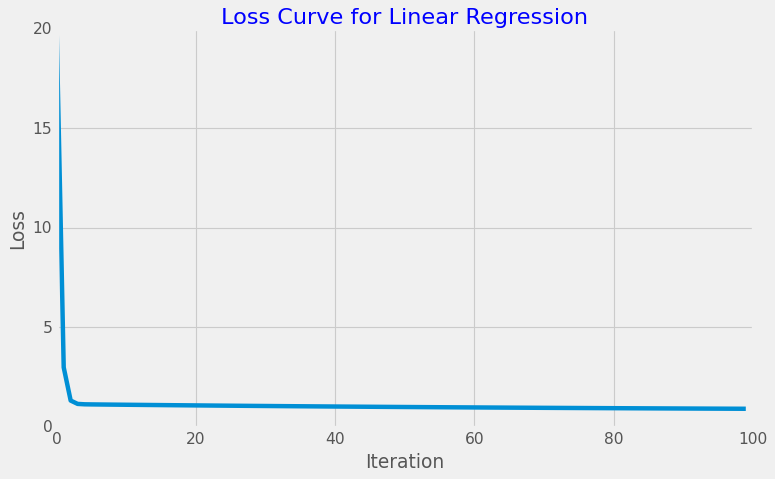

In [86]:
### Plotting Loss Curve
w_final, b_final, losses = gradient_descent_linear(X, y)
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Curve for Linear Regression', color='b')
plt.grid(True)
if save_figs==True:
    plt.savefig("linear_regression_loss.png")
plt.show()


# Conclusion
This notebook demonstrates gradient descent development under different learning rates and applies it to a quadratic function. Additionally gradient descent setup is applied to a simple linear regression equation.
